# CS131 — GitHub Archive: Data Engineering & Exploration
**Kernel:** CS131 (venv)

This notebook characterizes the GH Archive dataset from a **one-hour sample**
(~267k events). The goal is *understanding*, not full processing — the full
dataset is handled by CLI streaming (Phase 1) and PySpark on Dataproc (Phase 3).

Run top-to-bottom with **Shift+Enter**. Each section prints results and draws a chart.

## 0. Setup — load one hour into a DataFrame

In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)

# Find repo root no matter where the kernel started
ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SAMPLE = ROOT / "data/sample/2024-01-15-15.json.gz"
print("Reading:", SAMPLE)

df = pd.read_json(SAMPLE, lines=True, compression="gzip")
print("shape:", df.shape)      # (rows, columns)
df.head(3)

Reading: /home/ishigaki-cs6/final_project/data/sample/2024-01-15-15.json.gz


shape: (266871, 8)


,id,type,actor,repo,payload,public,created_at,org
0,34834865479,CreateEvent,"{'id': 140599107, 'login': 'prasham04', 'displ...","{'id': 743589745, 'name': 'prasham04/SImon-gam...","{'ref': None, 'ref_type': 'repository', 'maste...",True,2024-01-15 15:00:00+00:00,NaN
1,34834865487,CreateEvent,"{'id': 49699333, 'login': 'dependabot[bot]', '...","{'id': 223893722, 'name': 'dm-drogeriemarkt/li...",{'ref': 'dependabot/npm_and_yarn/react-router-...,True,2024-01-15 15:00:00+00:00,"{'id': 26007276, 'login': 'dm-drogeriemarkt', ..."
2,34834865488,PushEvent,"{'id': 118571769, 'login': 'abdelemjidessaid',...","{'id': 741908301, 'name': 'abdelemjidessaid/al...","{'repository_id': 741908301, 'push_id': 166455...",True,2024-01-15 15:00:00+00:00,NaN


## 1. Schema
Every event has the same 7 top-level keys. `repo`, `actor`, and `payload` are
**nested** (dicts) — a big reason Excel/CSV tools struggle and why JSON-aware
tools (jq, Spark) fit better.

In [2]:
print("columns:", df.columns.tolist())
df.dtypes

columns: ['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']


id                          int64
type                          str
actor                      object
repo                       object
payload                    object
public                       bool
created_at    datetime64[us, UTC]
org                        object
dtype: object

## 2. Flatten the nested `repo` / `actor` structs into flat columns

In [3]:
df["repo_name"]   = df["repo"].apply(lambda r: r.get("name")  if isinstance(r, dict) else None)
df["actor_login"] = df["actor"].apply(lambda a: a.get("login") if isinstance(a, dict) else None)
df["hour"]        = pd.to_datetime(df["created_at"]).dt.strftime("%Y-%m-%d %H:00")
df[["type", "created_at", "repo_name", "actor_login"]].head()

,type,created_at,repo_name,actor_login
0,CreateEvent,2024-01-15 15:00:00+00:00,prasham04/SImon-game,prasham04
1,CreateEvent,2024-01-15 15:00:00+00:00,dm-drogeriemarkt/lisa,dependabot[bot]
2,PushEvent,2024-01-15 15:00:00+00:00,abdelemjidessaid/alx-backend-python,abdelemjidessaid
3,PushEvent,2024-01-15 15:00:00+00:00,oss333ulf/Projcts9,oss333ulf
4,PushEvent,2024-01-15 15:00:00+00:00,k-46/nand2Tetris-part-1,k-46


## 3. Event-type distribution — what kinds of activity exist?

type
PushEvent                        169030
CreateEvent                       28616
PullRequestEvent                  18272
IssueCommentEvent                 11687
WatchEvent                         9548
DeleteEvent                        7556
PullRequestReviewEvent             7217
PullRequestReviewCommentEvent      4311
IssuesEvent                        4170
ForkEvent                          2373
ReleaseEvent                       1247
PublicEvent                         891
CommitCommentEvent                  815
MemberEvent                         724
GollumEvent                         414
Name: count, dtype: int64


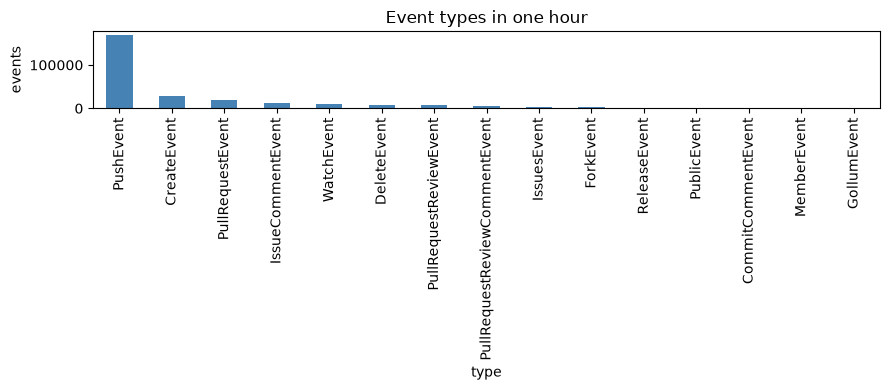


PushEvent is 63.3% of all events.


In [4]:
vc = df["type"].value_counts()
print(vc)
ax = vc.plot.bar(color="steelblue", title="Event types in one hour")
ax.set_ylabel("events"); plt.tight_layout(); plt.show()
print(f"\nPushEvent is {vc['PushEvent']/len(df):.1%} of all events.")

## 4. Cardinality — how many distinct repos / actors?
High cardinality (tens of thousands of distinct repos per hour) is exactly the
kind of thing `sort | uniq` on the full file, or a Spark `groupBy`, handles well.

In [5]:
print("distinct repos :", df["repo_name"].nunique())
print("distinct actors:", df["actor_login"].nunique())
print("total events   :", len(df))

distinct repos : 81373
distinct actors: 66135
total events   : 266871


## 5. Data-quality check — bots dominate raw activity
GitHub automation (`github-actions[bot]`, `dependabot[bot]`, `renovate[bot]`)
and spam accounts produce a huge share of events. Raw counts **overstate human
activity**, so we flag bots and report both.

actor_login
github-actions[bot]    19295
inse2233tto            17689
ion561sdag             17660
dependabot[bot]         9936
akinotaxe653            7703
oss333ulf               4464
aiccac                  4369
LMAO-armv8              3324
renovate[bot]           3137
bommix                  1757
mdmaid69                1470
B74LABgit               1034
Name: count, dtype: int64

bot vs human events:
 is_bot
False    227934
True      38937
Name: count, dtype: int64


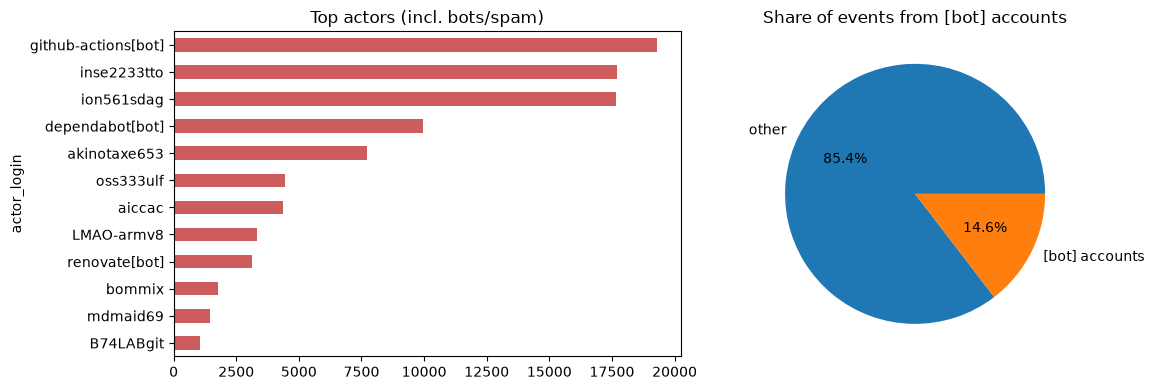

In [6]:
top_actors = df["actor_login"].value_counts().head(12)
print(top_actors)
df["is_bot"] = df["actor_login"].fillna("").str.contains(r"\[bot\]$", regex=True)
by_bot = df["is_bot"].value_counts()
print("\nbot vs human events:\n", by_bot)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
top_actors.plot.barh(ax=a1, color="indianred", title="Top actors (incl. bots/spam)")
a1.invert_yaxis()
by_bot.rename({True:"[bot] accounts", False:"other"}).plot.pie(
    ax=a2, autopct="%1.1f%%", ylabel="", title="Share of events from [bot] accounts")
plt.tight_layout(); plt.show()

## 6. Numeric aggregate — commits per push (the `awk` job, in pandas)

pushes=169,030  total_commits=679,685  avg=4.02


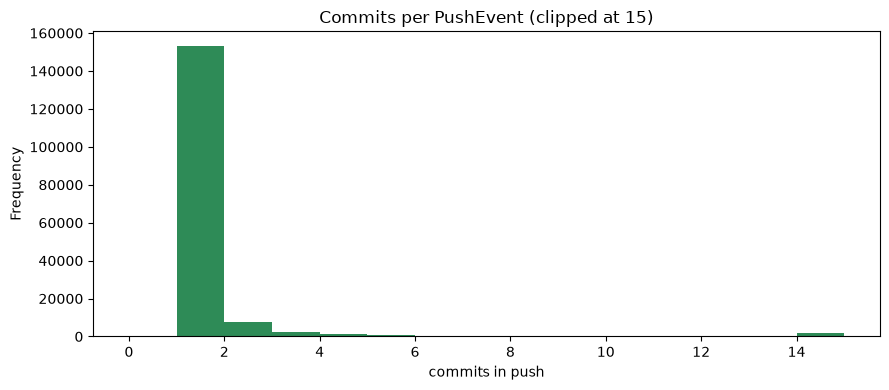

In [7]:
push = df[df["type"]=="PushEvent"].copy()
push["commits"] = push["payload"].apply(lambda p: p.get("size", 0) if isinstance(p, dict) else 0)
print(f"pushes={len(push):,}  total_commits={push['commits'].sum():,}  avg={push['commits'].mean():.2f}")
ax = push["commits"].clip(upper=15).plot.hist(bins=15, color="seagreen",
        title="Commits per PushEvent (clipped at 15)")
ax.set_xlabel("commits in push"); plt.tight_layout(); plt.show()

## 7. The project question, previewed — AI/ML vs general repos
Classify each event's repo as AI/ML by name pattern, then compare the **event
mix**. Even in one hour, AI/ML repos get **starred (WatchEvent) far more often**
than the average repo — an early signal for our 2021→2026 question.

repo_class
general    264663
ai_ml        2208
Name: count, dtype: int64

WatchEvent (star) share:
repo_class
ai_ml      16.44
general     3.47
Name: WatchEvent, dtype: float64


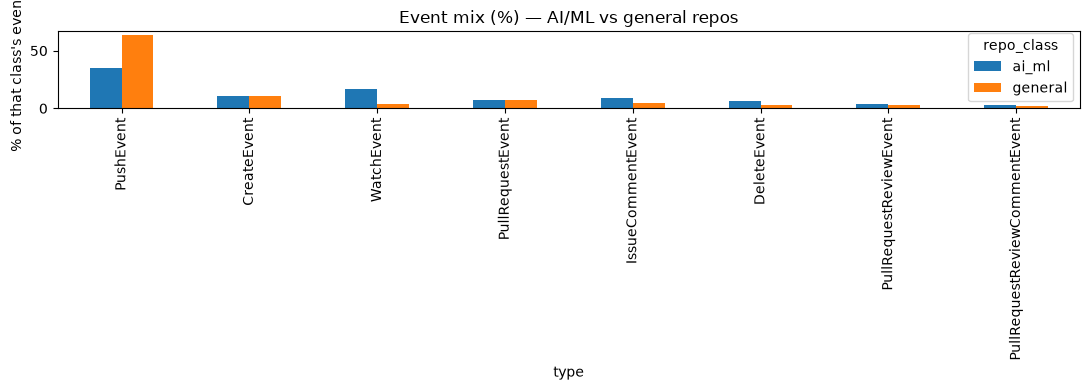

In [8]:
AI_PAT = re.compile(r"(?:llm|gpt|pytorch|tensorflow|langchain|diffus|transformer|"
                    r"huggingface|openai|deep.?learning|neural|machine.?learning|"
                    r"agentic|rag-)", re.I)
df["repo_class"] = df["repo_name"].fillna("").str.contains(AI_PAT).map({True:"ai_ml", False:"general"})
print(df["repo_class"].value_counts())

# event-type mix (%) within each class
mix = (df.groupby("repo_class")["type"].value_counts(normalize=True)
         .mul(100).rename("pct").reset_index())
pivot = mix.pivot(index="type", columns="repo_class", values="pct").fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index].head(8)
print("\nWatchEvent (star) share:")
print(pivot.loc["WatchEvent"].round(2))

ax = pivot.plot.bar(figsize=(11,4), title="Event mix (%) — AI/ML vs general repos")
ax.set_ylabel("% of that class's events"); plt.tight_layout(); plt.show()

## 8. What breaks, and what scales
- **This notebook loaded ONE hour** (~1 GB uncompressed) — fine in RAM.
- The **full dataset is ~50M+ rows / >5 GB** → `pd.read_json` on all of it OOMs
  (Phase 2). We reproduce that crash with the `ulimit` recipe in `2_breaking/`.
- The exact same logic (flatten → classify → groupBy) runs on the whole thing in
  **PySpark on Dataproc** (`3_scaling/spark_job.py`), reading from GCS.

**Takeaway:** streaming/distributed tools do at scale what pandas can only do on a slice.